In [1]:
# === File system and utility handling ===
import os
import sys
import shutil
import re
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# === Data manipulation ===
import pandas as pd
import numpy as np

# === Google Drive integration (Colab only) ===
from google.colab import drive
from google.colab import files

# === Plotting and visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Clustering ===
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Load and Prepare Data

In [2]:
!wget https://raw.githubusercontent.com/Edenshmuel/MIMIC_ICU_Prediction_and_Clustering/main/Preprocessing.py

--2025-07-13 13:49:47--  https://raw.githubusercontent.com/Edenshmuel/MIMIC_ICU_Prediction_and_Clustering/main/Preprocessing.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7242 (7.1K) [text/plain]
Saving to: ‘Preprocessing.py’

Preprocessing.py    100%[===================>]   7.07K  --.-KB/s    in 0s      

2025-07-13 13:49:48 (54.7 MB/s) - ‘Preprocessing.py’ saved [7242/7242]



Import & Load Data

In [3]:
# Import preprocessing
from Preprocessing import build_pipeline, filter_age, remove_rows_with_many_missing

In [4]:
# Load the data
url = "https://raw.githubusercontent.com/Edenshmuel/MIMIC_ICU_Prediction_and_Clustering/refs/heads/main/MIMIC_data_sample_mortality.csv"
df = pd.read_csv(url)

Clean Data

In [5]:
# Clean your dataframe of bad rows all at once:
df_clean = (
    df
    .pipe(filter_age)
    .pipe(remove_rows_with_many_missing))

Build Pipeline

In [6]:
# Build pipeline
pipeline_builder = build_pipeline()
pipe = pipeline_builder(df_clean)

Fit-Transform Data

In [8]:
# Fit on full data and transform
X_cluster = pipe.fit_transform(df_clean)

Get Feature Names From ColumnTransformer

In [9]:
feature_names = []

for name, transformer, cols in pipe.named_steps['transform'].transformers_:
    if name == 'impute_and_scale':
        feature_names.extend(cols)
    elif name == 'binary_passthrough':
        feature_names.extend(cols)

Build DataFrame With Feature Names

In [10]:
X_cluster_df = pd.DataFrame(X_cluster, columns=feature_names)

Drop outcome variables so they are not used to form clusters

In [11]:
X_cluster_only = X_cluster_df.drop(columns=['thirtyday_expire_flag', 'icu_los'])

### K-means clustering

**Determining the optimal number of clusters using the Elbow and Silhouette methods**


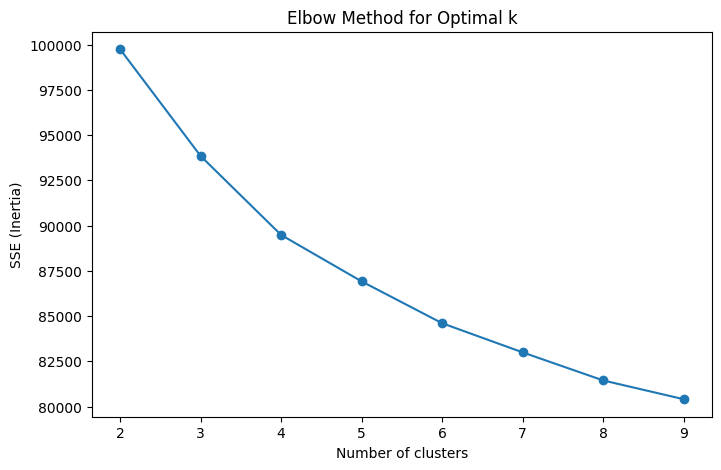

In [12]:
# Elbow method to find optimal k
sse = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster_only)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 10), sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('SSE (Inertia)')
plt.show()

The elbow plot suggests an optimal choice of around 3 clusters. We’ll verify this by checking the silhouette scores

In [13]:
# Silhouette score for a quick check
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_cluster_only)
    sil = silhouette_score(X_cluster_only, labels)
    print(f'Silhouette score for k={k}: {sil:.4f}')

Silhouette score for k=2: 0.0984
Silhouette score for k=3: 0.0665
Silhouette score for k=4: 0.0678
Silhouette score for k=5: 0.0516


Given the small differences in silhouette scores between k=3 and k=4, and the exploratory goal of identifying clinically meaningful subgroups, we will examine both clustering solutions

**Fit the final models for k=3**

In [14]:
# Fit KMeans with k=3
kmeans3 = KMeans(n_clusters=3, random_state=42)
X_cluster_only['cluster_3'] = kmeans3.fit_predict(X_cluster)

**Fit the final models for k=4**

In [15]:
# Fit KMeans with k=4
kmeans3 = KMeans(n_clusters=4, random_state=42)
X_cluster_only['cluster_4'] = kmeans3.fit_predict(X_cluster)

**Summarize clusters**

K = 3

In [16]:
print(X_cluster_only.groupby('cluster_3').mean())

                age      sofa  creatinine_max  chloride_max  glucose_max  \
cluster_3                                                                  
0         -0.938760 -0.275788       -0.515558      0.222785    -0.085923   
1          0.223235  0.922698        1.042127      0.108333     0.513918   
2          0.585936 -0.366559       -0.256129     -0.240437    -0.256524   

           hemoglobin_max  lactate_max  platelet_min  potassium_min  \
cluster_3                                                             
0                0.379971     0.029050     -0.059456      -0.412541   
1               -0.088100     0.620051     -0.266116       0.425215   
2               -0.238581    -0.412174      0.213249       0.051901   

           potassium_max  ...  age_rounded   is_male  race_white  race_black  \
cluster_3                 ...                                                  
0              -0.271866  ...    -0.927807  0.601637    0.640518    0.090041   
1               0.66063

K = 4

In [17]:
print(X_cluster_only.groupby('cluster_4').mean())

                age      sofa  creatinine_max  chloride_max  glucose_max  \
cluster_4                                                                  
0          0.608900 -0.347843       -0.317876     -0.133784    -0.432146   
1          0.214879  0.187101        0.080266      0.025028     1.191360   
2          0.202555  1.032845        1.454717     -0.110375    -0.142685   
3         -1.048013 -0.322707       -0.537434      0.217218    -0.240585   

           hemoglobin_max  lactate_max  platelet_min  potassium_min  \
cluster_4                                                             
0               -0.256155    -0.419212      0.158485      -0.010494   
1                0.214966     0.393544      0.018131      -0.010882   
2               -0.305577     0.463519     -0.265869       0.706536   
3                0.350618    -0.039488     -0.052445      -0.406068   

           potassium_max  ...  age_rounded   is_male  race_white  race_black  \
cluster_4                 ...       

**Mortality rates across identified clusters**

In [20]:
X_cluster_df['cluster_3'] = X_cluster_only['cluster_3']
X_cluster_df['cluster_4'] = X_cluster_only['cluster_4']

K = 3

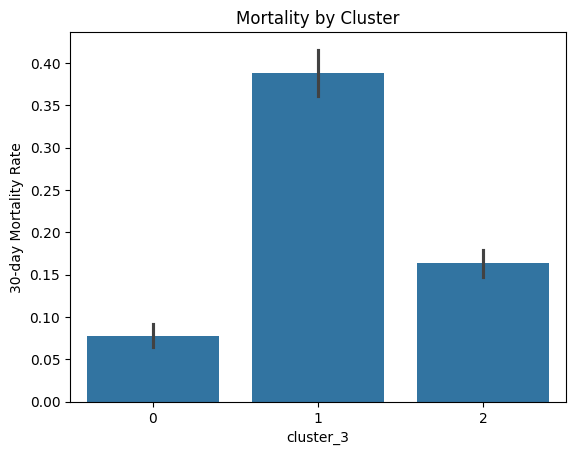

In [21]:
sns.barplot(x='cluster_3', y='thirtyday_expire_flag', data=X_cluster_df)
plt.ylabel('30-day Mortality Rate')
plt.title('Mortality by Cluster')
plt.show()

The plot shows that mortality rates differ substantially across the clusters.
Cluster 1 exhibits the highest 30-day mortality, suggesting it represents the sickest patient group,
while Cluster 0 has the lowest mortality.


K = 4

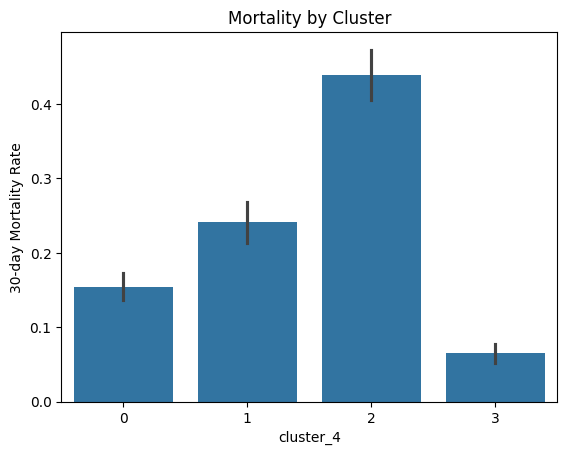

In [23]:
sns.barplot(x='cluster_4', y='thirtyday_expire_flag', data=X_cluster_df)
plt.ylabel('30-day Mortality Rate')
plt.title('Mortality by Cluster')
plt.show()

The plot shows that mortality rates vary substantially across the 4 clusters.
Cluster 2 has the highest 30-day mortality (over 40%), suggesting it captures the most critically ill patients.
Cluster 3 have notably lower mortality rate, indicating he represent lower-risk subgroups

**ICU length of stay across clusters**

K = 3

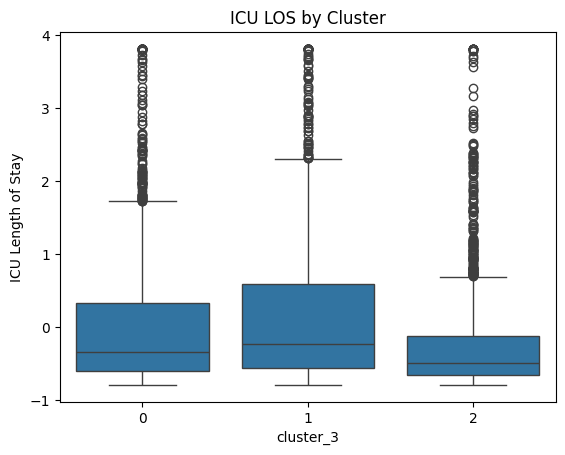

In [22]:
sns.boxplot(x='cluster_3', y='icu_los', data=X_cluster_df)
plt.ylabel('ICU Length of Stay')
plt.title('ICU LOS by Cluster')
plt.show()

This boxplot shows that ICU length of stay tends to be slightly higher in Cluster 1,
which also had the highest mortality, suggesting it may capture patients with more severe or prolonged illness.
Clusters 0 and 2 have somewhat lower median stays.

K = 4

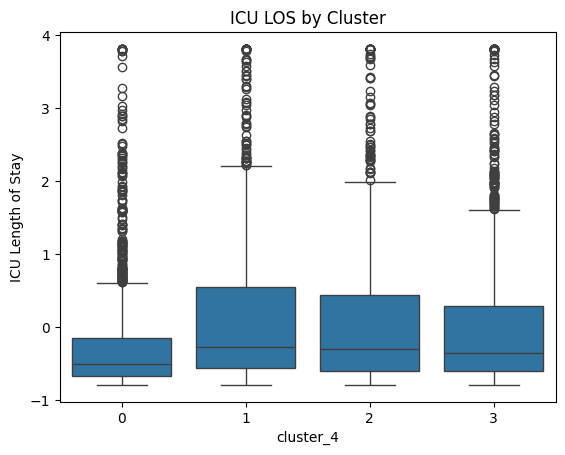

In [25]:
sns.boxplot(x='cluster_4', y='icu_los', data=X_cluster_df)
plt.ylabel('ICU Length of Stay')
plt.title('ICU LOS by Cluster')
plt.show()

ICU length of stay appears moderately higher in Clusters 1 and 2, which also showed elevated mortality.
Clusters 0 and 3 have shorter stays, suggesting they represent lower-risk groups with faster ICU discharge

**Mean mortality and ICU length of stay by cluster**

In [27]:
print(X_cluster_df.groupby('cluster_3')[['thirtyday_expire_flag', 'icu_los']].mean())

           thirtyday_expire_flag   icu_los
cluster_3                                 
0                       0.077763  0.087459
1                       0.387909  0.246899
2                       0.164116 -0.222835


Cluster 1 has the highest 30-day mortality rate (38.7%) and also the longest ICU stays,
suggesting it captures a higher-risk patient group.
Cluster 0 has the lowest mortality, while Cluster 2 appears intermediate in mortality but with slightly shorter ICU stays.


In [26]:
print(X_cluster_df.groupby('cluster_4')[['thirtyday_expire_flag', 'icu_los']].mean())

           thirtyday_expire_flag   icu_los
cluster_4                                 
0                       0.154135 -0.244402
1                       0.240821  0.192263
2                       0.439216  0.155242
3                       0.064822  0.073731


With 4 clusters, Cluster 2 shows the highest mortality rate (43.9%), while Cluster 0 and Cluster 3 have notably lower mortality.
ICU length of stay differences are modest across clusters, suggesting that the primary distinction in this solution is mortality risk

**Characterization of clinical clusters and identification of key risk factors**

In [29]:
print(X_cluster_df.groupby('cluster_3')[['sofa', 'lactate_max', 'creatinine_max', 'age', 'bun_mean', 'urineoutput', 'hemoglobin_max', 'vent', 'glucose_mean', 'spo2_mean']].mean())

               sofa  lactate_max  creatinine_max       age  bun_mean  \
cluster_3                                                              
0         -0.275788     0.029050       -0.515558 -0.938760 -0.754623   
1          0.922698     0.620051        1.042127  0.223235  0.969153   
2         -0.366559    -0.412174       -0.256129  0.585936 -0.025321   

           urineoutput  hemoglobin_max      vent  glucose_mean  spo2_mean  
cluster_3                                                                  
0             0.528831        0.379971  0.685539     -0.121708   0.261773  
1            -0.747371       -0.088100  0.627204      0.416578  -0.157659  
2             0.060608       -0.238581  0.408971     -0.167662  -0.103424  


In [30]:
print(X_cluster_df.groupby('cluster_4')[['sofa', 'lactate_max', 'creatinine_max', 'age', 'bun_mean', 'urineoutput', 'hemoglobin_max', 'vent', 'glucose_mean', 'spo2_mean']].mean())

               sofa  lactate_max  creatinine_max       age  bun_mean  \
cluster_4                                                              
0         -0.347843    -0.419212       -0.317876  0.608900 -0.097966   
1          0.187101     0.393544        0.080266  0.214879  0.259031   
2          1.032845     0.463519        1.454717  0.202555  1.236596   
3         -0.322707    -0.039488       -0.537434 -1.048013 -0.813838   

           urineoutput  hemoglobin_max      vent  glucose_mean  spo2_mean  
cluster_4                                                                  
0             0.071498       -0.256155  0.427318     -0.408003  -0.043301  
1            -0.009180        0.214966  0.600432      1.313608  -0.120276  
2            -1.034300       -0.305577  0.559477     -0.263034  -0.231293  
3             0.541999        0.350618  0.680632     -0.287753   0.282548  


**Deciding between 3 and 4 clusters based on t-SNE visualization**

After completing all statistical checks and cluster summaries for k=3 and k=4, we use t-SNE visualization to assess how well-separated the clusters appear in local structure. This helps guide our final choice of the most meaningful clustering solution.

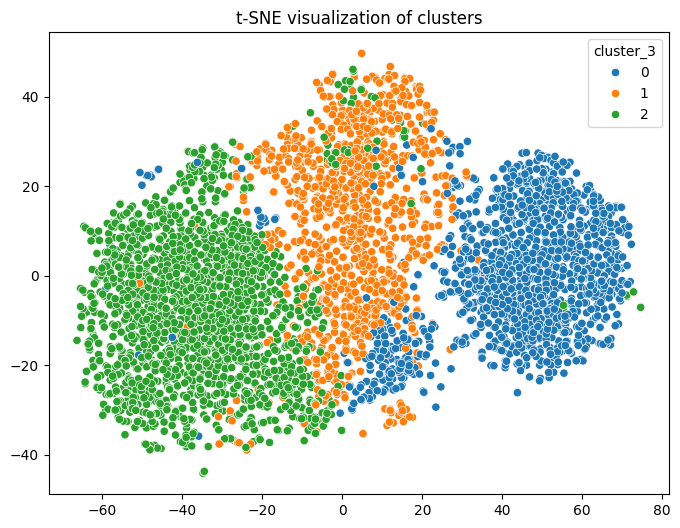

In [37]:
from sklearn.manifold import TSNE

# Fit t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_cluster_only)

# Plot t-SNE
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=X_cluster_df['cluster_3'], palette='tab10')
plt.title('t-SNE visualization of clusters')
plt.show()

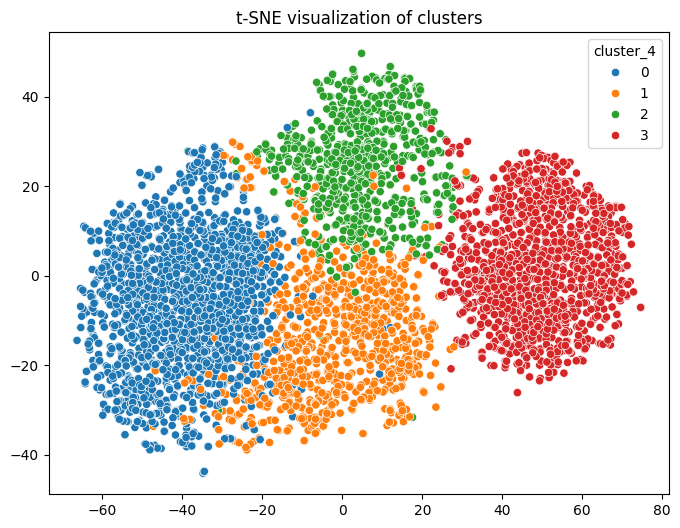

In [38]:
# Fit t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_cluster_only)

# Plot t-SNE
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=X_cluster_df['cluster_4'], palette='tab10')
plt.title('t-SNE visualization of clusters')
plt.show()

Based on our comprehensive analysis, including the elbow and silhouette methods, detailed clinical summaries of key features, and finally the t-SNE visualization of local cluster structure, we decided to proceed with 4 clusters (k=4).

The t-SNE plots demonstrated that the fourth cluster formed a well-separated, distinct group, suggesting it captures an important clinical phenotype that would have been masked in a simpler three-cluster solution. This provides a more nuanced stratification of our ICU cohort, which we will explore in subsequent analyses.

**Compare clusters on key variable**

In [39]:
cluster_summary = X_cluster_df.groupby('cluster_4')[['sofa', 'lactate_max', 'creatinine_max', 'age', 'bun_mean', 'urineoutput', 'hemoglobin_max', 'vent', 'glucose_mean', 'spo2_mean']].agg(['mean', 'std'])
print(cluster_summary)

               sofa           lactate_max           creatinine_max            \
               mean       std        mean       std           mean       std   
cluster_4                                                                      
0         -0.347843  0.838379   -0.419212  0.707716      -0.317876  0.613809   
1          0.187101  0.975394    0.393544  1.047393       0.080266  0.784378   
2          1.032845  0.740471    0.463519  1.195648       1.454717  1.056243   
3         -0.322707  0.870867   -0.039488  0.914003      -0.537434  0.546926   

                age            bun_mean           urineoutput            \
               mean       std      mean       std        mean       std   
cluster_4                                                                 
0          0.608900  0.638229 -0.097966  0.739966    0.071498  0.715017   
1          0.214879  0.757135  0.259031  0.806327   -0.009180  0.857274   
2          0.202555  0.881544  1.236596  0.743762   -1.034300  1

- Cluster 2

    Highest SOFA, lactate, creatinine, BUN — generally looks like the sickest group.

    Lower urine output, lower SpO2.

    More ventilation.

    Matches highest mortality.

- Cluster 3

    Lower SOFA & lactate, slightly better kidney markers.

    But interestingly has higher urine output & slightly higher SpO2.

    Looks like an older group (age is lowest negative z-score) with possibly different risk profile.

- Cluster 0

    Mid-range SOFA, moderate labs, not extreme on any feature.

    Could be an intermediate-risk group.

    Cluster 1

    Generally lower creatinine & lactate, higher urine output, best glucose.

    Likely the lowest risk group.

**Test statistical differences**

ANOVA for continuous variables

In [41]:
from scipy.stats import f_oneway

for col in ['sofa', 'lactate_max', 'creatinine_max', 'age', 'bun_mean',
            'urineoutput', 'hemoglobin_max', 'vent', 'glucose_mean', 'spo2_mean', 'icu_los']:
    fval, pval = f_oneway(
        X_cluster_df.loc[X_cluster_df['cluster_4'] == 0, col],
        X_cluster_df.loc[X_cluster_df['cluster_4'] == 1, col],
        X_cluster_df.loc[X_cluster_df['cluster_4'] == 2, col],
        X_cluster_df.loc[X_cluster_df['cluster_4'] == 3, col]
    )
    print(f"ANOVA p-value for {col}: {pval:.4f}")

ANOVA p-value for sofa: 0.0000
ANOVA p-value for lactate_max: 0.0000
ANOVA p-value for creatinine_max: 0.0000
ANOVA p-value for age: 0.0000
ANOVA p-value for bun_mean: 0.0000
ANOVA p-value for urineoutput: 0.0000
ANOVA p-value for hemoglobin_max: 0.0000
ANOVA p-value for vent: 0.0000
ANOVA p-value for glucose_mean: 0.0000
ANOVA p-value for spo2_mean: 0.0000
ANOVA p-value for icu_los: 0.0000


Chi-squared for categorical (e.g. ventilation, cancer)

In [42]:
import scipy.stats as stats

# For ventilation
contingency_table_vent = pd.crosstab(X_cluster_df['cluster_4'], X_cluster_df['vent'])
chi2_vent, p_vent, _, _ = stats.chi2_contingency(contingency_table_vent)
print(f"Chi-squared p-value for ventilation across clusters: {p_vent:.4f}")

# For 30-day mortality
contingency_table_mort = pd.crosstab(X_cluster_df['cluster_4'], X_cluster_df['thirtyday_expire_flag'])
chi2_mort, p_mort, _, _ = stats.chi2_contingency(contingency_table_mort)
print(f"Chi-squared p-value for 30-day mortality across clusters: {p_mort:.4f}")

Chi-squared p-value for ventilation across clusters: 0.0000
Chi-squared p-value for 30-day mortality across clusters: 0.0000


We performed ANOVA tests across the four identified clusters, finding statistically significant differences (p < 0.0001) in all key clinical features, including SOFA scores, lactate, creatinine, age, and ICU length of stay.
Similarly, chi-squared tests revealed significant differences in both ventilation usage and 30-day mortality rates across clusters (p < 0.0001).
These results suggest that the clustering meaningfully stratifies patients into clinically distinct subgroups.

**Determining which clusters differ significantly: pairwise statistical tests**

Tukey HSD for continuous variables

In [43]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# List of continuous variables
continuous_vars = ['sofa', 'lactate_max', 'creatinine_max', 'bun_mean', 'age',
                   'urineoutput', 'hemoglobin_max', 'glucose_mean', 'spo2_mean', 'icu_los']

# Loop through and run Tukey HSD for each
for var in continuous_vars:
    tukey = pairwise_tukeyhsd(endog=X_cluster_df[var],
                              groups=X_cluster_df['cluster_4'],
                              alpha=0.05)
    print(f"\nTukey HSD results for {var}:")
    print(tukey.summary())



Tukey HSD results for sofa:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   0.5349    0.0  0.4434  0.6264   True
     0      2   1.3807    0.0  1.2833  1.4781   True
     0      3   0.0251 0.8659 -0.0582  0.1085  False
     1      2   0.8457    0.0  0.7375   0.954   True
     1      3  -0.5098    0.0 -0.6056  -0.414   True
     2      3  -1.3556    0.0  -1.457 -1.2541   True
----------------------------------------------------

Tukey HSD results for lactate_max:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   0.8128    0.0  0.7137  0.9118   True
     0      2   0.8827    0.0  0.7773  0.9882   True
     0      3   0.3797    0.0  0.2894    0.47   True
     1      2     0.07 0.4168 -0.0472  0.1872  False
     1      3   -0.433    0.0 -0.5

categorical outcomes (mortality, ventilation)

In [44]:
from scipy.stats import chi2_contingency

categorical_vars = ['thirtyday_expire_flag', 'vent']
clusters = X_cluster_df['cluster_4'].unique()

for var in categorical_vars:
    print(f"\nPairwise chi-squared tests for {var}:")
    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            subset = X_cluster_df[X_cluster_df['cluster_4'].isin([clusters[i], clusters[j]])]
            contingency_table = pd.crosstab(subset['cluster_4'], subset[var])
            chi2, p, _, _ = chi2_contingency(contingency_table)
            print(f"Clusters {clusters[i]} vs {clusters[j]}: p-value = {p:.4f}")



Pairwise chi-squared tests for thirtyday_expire_flag:
Clusters 2 vs 1: p-value = 0.0000
Clusters 2 vs 0: p-value = 0.0000
Clusters 2 vs 3: p-value = 0.0000
Clusters 1 vs 0: p-value = 0.0000
Clusters 1 vs 3: p-value = 0.0000
Clusters 0 vs 3: p-value = 0.0000

Pairwise chi-squared tests for vent:
Clusters 2 vs 1: p-value = 0.0990
Clusters 2 vs 0: p-value = 0.0000
Clusters 2 vs 3: p-value = 0.0000
Clusters 1 vs 0: p-value = 0.0000
Clusters 1 vs 3: p-value = 0.0001
Clusters 0 vs 3: p-value = 0.0000


**Results**

- For continuous variables (Tukey HSD)
    Almost all clusters differ significantly on SOFA, lactate, creatinine, BUN, age, urine output, hemoglobin, glucose, SpO2, and ICU LOS (most p-adj < 0.0001).

    A few exceptions where differences are not significant (for example):

    - SOFA: cluster 0 vs 3 (p=0.8659), meaning similar SOFA.

    - Lactate: cluster 1 vs 2 (p=0.4168).

    - Age: cluster 1 vs 2 (p=0.9864).

    - Glucose: cluster 2 vs 3 (p=0.8877).

    - ICU LOS: cluster 1 vs 2 (p=0.8677), cluster 2 vs 3 (p=0.2687).

- For categorical outcomes (Chi²)
Mortality (thirtyday_expire_flag):

    Extremely strong separation — all cluster pairs differ significantly (p < 0.0001). This shows your clustering stratifies mortality very clearly.



Pairwise comparisons using Tukey HSD and chi-squared tests demonstrated that the four identified clusters differ significantly across nearly all key clinical features, including SOFA, lactate, creatinine, BUN, age, urine output, glucose, SpO2, and ICU length of stay. Mortality rates were significantly different between all cluster pairs (p < 0.0001), while ventilation usage also showed significant differences in most comparisons. This highlights the robustness of our clustering in capturing clinically meaningful patient subgroups

**Visualize clusters**

Boxplots for key features

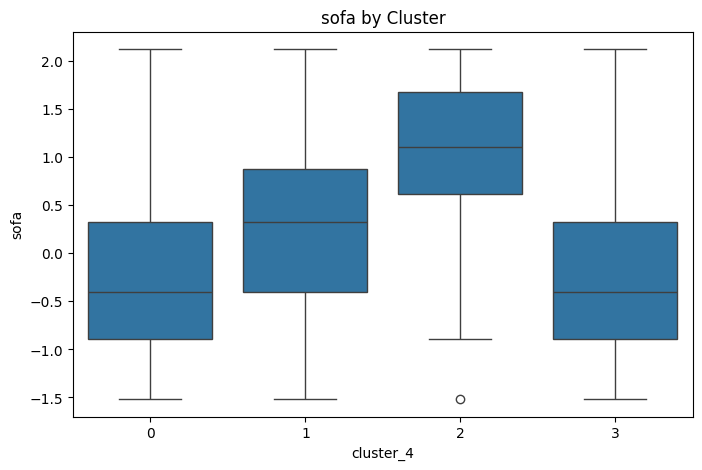

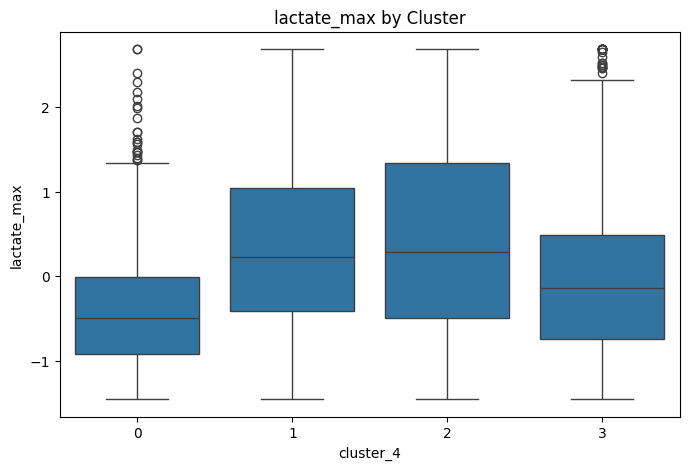

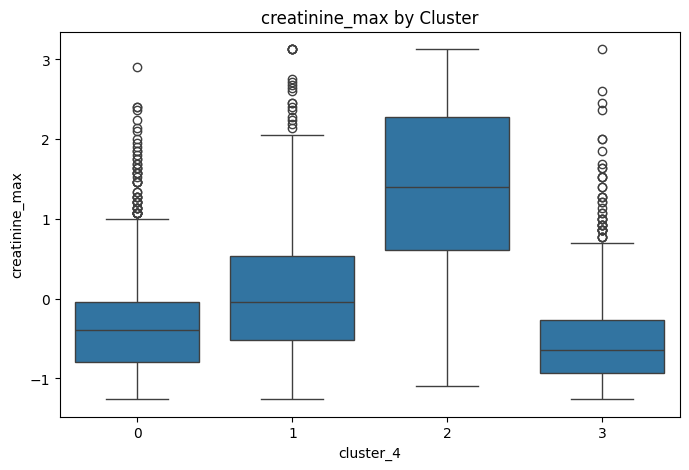

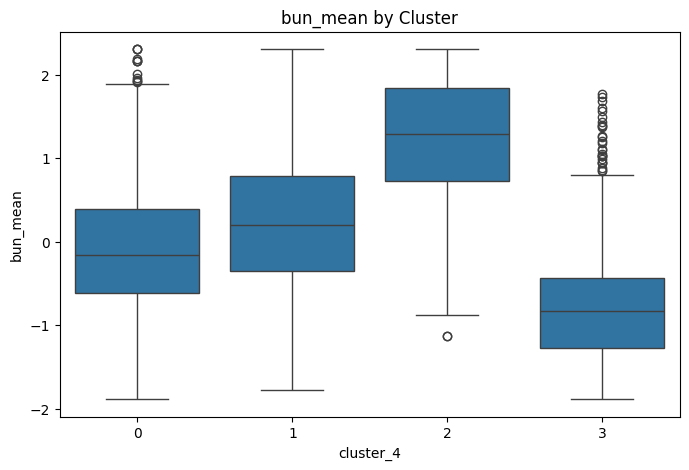

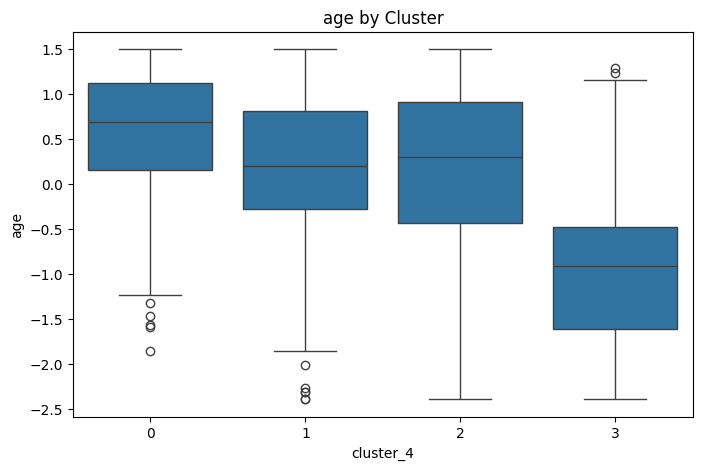

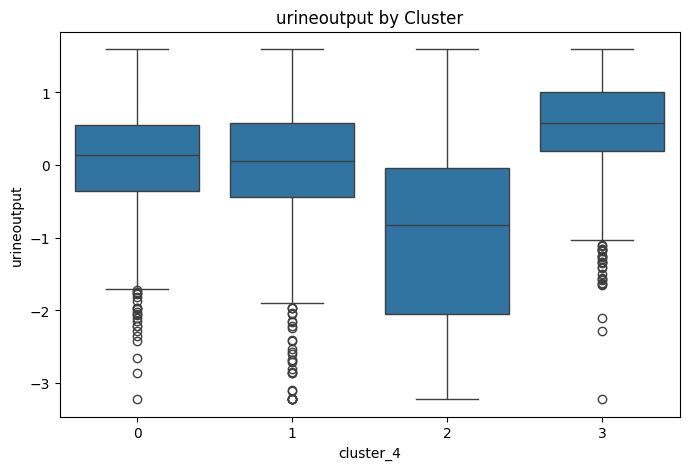

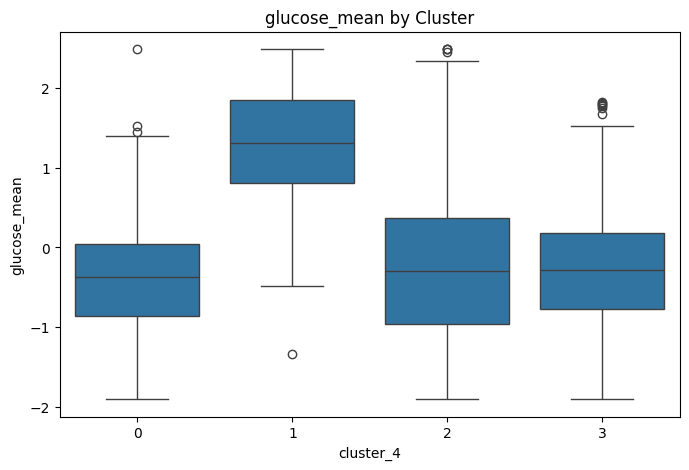

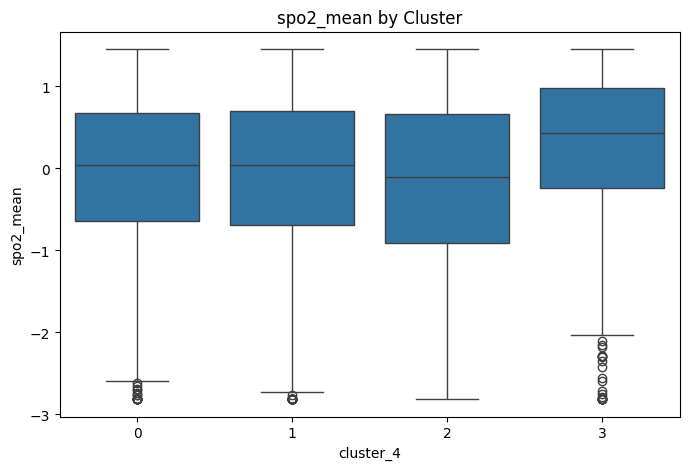

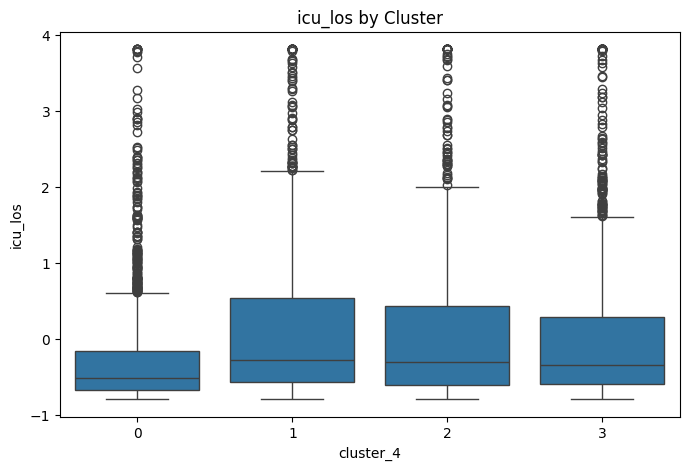

In [45]:
features = ['sofa', 'lactate_max', 'creatinine_max', 'bun_mean', 'age',
            'urineoutput', 'glucose_mean', 'spo2_mean', 'icu_los']

import seaborn as sns
import matplotlib.pyplot as plt

for feature in features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='cluster_4', y=feature, data=X_cluster_df)
    plt.title(f"{feature} by Cluster")
    plt.show()

- SOFA: Median SOFA scores are highest in cluster 2 and lowest in cluster 3.

- Lactate & creatinine: Elevated in cluster 2, suggesting worse metabolic and renal profiles.

- BUN & urine output: Cluster 2 again stands out with high BUN and low urine output.

- Age: Cluster 3 includes younger patients, whereas clusters 0 and 1 have higher age ranges.

- Glucose & SpO2: Show moderate differences, with slightly higher glucose in cluster 1.

- ICU length of stay: Longer in clusters 0 and 1, shorter in clusters 3.

PCA visualization of clusters

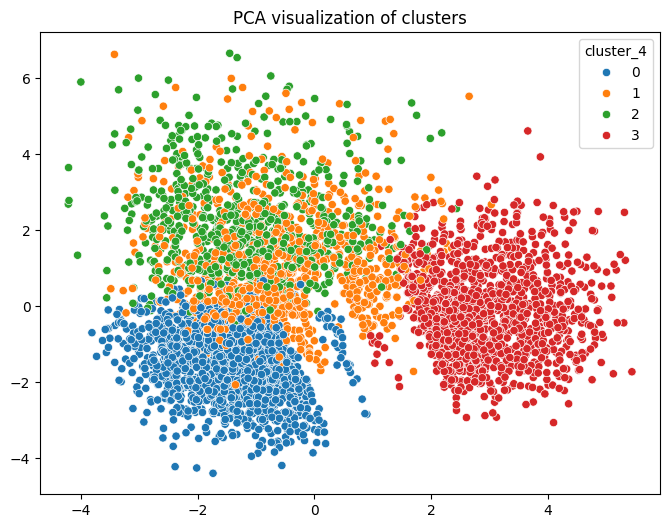

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_only)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=X_cluster_df['cluster_4'], palette='tab10')
plt.title('PCA visualization of clusters')
plt.show()

The PCA scatter plot shows a reasonably clear separation between the four clusters, particularly distinguishing cluster 3 (red) from the others. Clusters 0 (blue) and 1 (orange) exhibit some overlap, while cluster 2 (green) is moderately distinct. This supports the t-SNE findings and indicates meaningful group structure in the data

**Clinical interpretation**

Our analysis revealed four distinct clusters of ICU patients based on key clinical and laboratory features. These clusters demonstrate meaningful differences in patient characteristics, organ dysfunction markers, and outcomes:

- Cluster 2

    - Exhibits the highest levels of creatinine_max, BUN, and lactate, indicating significant renal dysfunction and metabolic derangements.

    - Also shows elevated SOFA scores, consistent with more severe multi-organ involvement.

    - This cluster had longer ICU stays and the highest 30-day mortality, highlighting a high-risk patient phenotype.

- Cluster 1

    - Characterized by moderately elevated lactate and SOFA scores, but relatively preserved urine output and lower creatinine levels compared to Cluster 2.

    - Shows intermediate ICU LOS and mortality, suggesting a moderate-risk group, potentially representing early or partially compensated organ dysfunction.

- Cluster 0

    - Displays lower SOFA scores, lower creatinine, and better urine output, consistent with less severe organ dysfunction.

    - Despite slightly older age than Cluster 3, this group had shorter ICU stays and lower mortality, aligning with a lower-risk phenotype.

- Cluster 3

    - Notably had the youngest patients, relatively preserved SOFA and lactate values, and lower BUN.

    - Also demonstrated lower 30-day mortality and shorter ICU LOS, representing a lower-acuity cohort, possibly with transient or isolated insults requiring ICU care.

These findings suggest that unsupervised clustering can effectively identify subgroups of ICU patients with distinct clinical profiles and outcomes. Recognizing these phenotypes may assist clinicians in early risk stratification, targeted monitoring, and potentially tailored therapeutic interventions.
